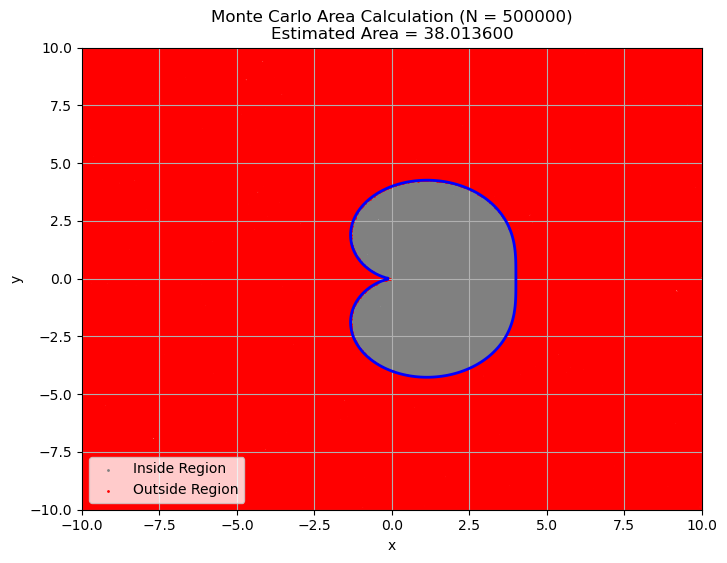

The estimated area of the region is: 38.013600


In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np

def monte_carlo_area(num_points):
    
    points_in_region = 0
    x_in_region = []
    y_in_region = []
    x_outside_region = []
    y_outside_region = []

    x_min, x_max = -10, 10
    y_min, y_max = -10, 10
    area_of_box = (x_max - x_min) * (y_max - y_min)

    for _ in range(num_points):
        x = random.uniform(x_min, x_max)
        y = random.uniform(y_min, y_max)

        if (x**2 + y**2 - 2*x)**2 <= 4 * (x**2 + 4*y**2):
            points_in_region += 1
            x_in_region.append(x)
            y_in_region.append(y)
        else:
            x_outside_region.append(x)
            y_outside_region.append(y)

    estimated_area = area_of_box * (points_in_region / num_points)

    plt.figure(figsize=(8, 6))

    plt.scatter(x_in_region, y_in_region, color='gray', s=1, label='Inside Region')
    plt.scatter(x_outside_region, y_outside_region, color='red', s=1, label='Outside Region')
    
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = np.linspace(y_min, y_max, 400)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    plt.contour(X, Y, (X**2 + Y**2 - 2*X)**2 - 4 * (X**2 + 4*Y**2), levels=[0], colors='blue', linewidths=2)
    
    plt.title(f'Monte Carlo Area Calculation (N = {num_points})\nEstimated Area = {estimated_area:.6f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

    return estimated_area

if __name__ == '__main__':
    num_points = 500000
    area = monte_carlo_area(num_points)
    
    print(f"The estimated area of the region is: {area:.6f}")